<a href="https://colab.research.google.com/github/Calebchike/Supermarket-Pulse/blob/Using-Python-Panda-Dataframe/Supermarket_Pulse_Using_Panda_Dataframe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [92]:
# Import necessary libraries: numpy for numerical operations and pandas for data manipulation.
import numpy as np
import pandas as pd

# **Load the CSV data**
Load Raw dataset, determine the rows and columns and convert columns to Panda series

In [93]:
# Load the supermarket sales data from a CSV file into a pandas DataFrame.
# The 'Invoice ID' column is set as the index.
# The .head() method is used to display the first few rows of the DataFrame.
supermarket_raw = pd.read_csv("https://raw.githubusercontent.com/Calebchike/Supermarket-Pulse/refs/heads/main/SuperMarket%20Analysis.csv", index_col="Invoice ID") #import supermarket csv file as a dataframe
supermarket_raw.head()                                         #prints the dataframe

,Branch,City_CustType,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
Invoice ID,,,,,,,,,,,,,,,
750-67-8428,Alex,Yangon|Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/2019,1:08:00 pm,Ewallet,522.83,4.761905,26.1415,9.1
226-31-3081,Giza,Naypyitaw|Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/2019,10:29:00 am,Cash,76.40,4.761905,3.8200,9.6
631-41-3108,Alex,Yangon|Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/2019,1:23:00 pm,Credit card,324.31,4.761905,16.2155,7.4
123-19-1176,Alex,Yangon|Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 pm,Ewallet,465.76,4.761905,23.2880,NaN
373-73-7910,Alex,Yangon|Member,Female,Sports and travel,86.31,7,30.2085,634.3785,02/08/2019,10:37:00 am,Ewallet,604.17,4.761905,30.2085,5.3


### Get the Number of Rows and Columns contained in the dataset

In [94]:
# Display the number of rows and columns in the DataFrame using the .shape attribute.
supermarket_raw.shape     #get the number of rows and column in the data

(1000, 15)

### Get all the column Headers in a List for referencing

In [95]:
# Get a list of all column headers (names) from the DataFrame.
supermarket_raw.columns.to_list()

['Branch',
 'City_CustType',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

# **Data Cleaning**

This cell creates a copy of the `supermarket_raw` DataFrame named `supermarket` for data cleaning and manipulation, leaving the original raw data unchanged.

In [96]:
supermarket = supermarket_raw.copy()

## Split Column
This cell Split "City_CustType" column into two separate columns using the |
delimiter. and Named them "City" and "Customer Type", and also drops the "City_CustType" column.

In [97]:
# Split the 'City_CustType' column into 'City' and 'Customer Type' and add them to the DataFrame.
# Then, drop the original 'City_CustType' column.

if 'City_CustType' in supermarket.columns:
    city_custtype = supermarket["City_CustType"]
    supermarket['City'] = city_custtype.str.split("|").str[0]
    supermarket['Customer Type'] = city_custtype.str.split("|").str[1]
    supermarket = supermarket.drop(columns=['City_CustType'])
display(supermarket.head())

,Branch,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,City,Customer Type
Invoice ID,,,,,,,,,,,,,,,,
750-67-8428,Alex,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/2019,1:08:00 pm,Ewallet,522.83,4.761905,26.1415,9.1,Yangon,Member
226-31-3081,Giza,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/2019,10:29:00 am,Cash,76.40,4.761905,3.8200,9.6,Naypyitaw,Normal
631-41-3108,Alex,Female,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/2019,1:23:00 pm,Credit card,324.31,4.761905,16.2155,7.4,Yangon,Normal
123-19-1176,Alex,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 pm,Ewallet,465.76,4.761905,23.2880,NaN,Yangon,Member
373-73-7910,Alex,Female,Sports and travel,86.31,7,30.2085,634.3785,02/08/2019,10:37:00 am,Ewallet,604.17,4.761905,30.2085,5.3,Yangon,Member


## Standardize Text
The Product line column has inconsistent capitalization. This cells Forces all text in the column to "Capitalize Each Word".

In [98]:
supermarket['Product line'] = supermarket['Product line'].str.strip().str.title()
supermarket['Product line'].head()

,Product line
Invoice ID,
750-67-8428,Health And Beauty
226-31-3081,Electronic Accessories
631-41-3108,Home And Lifestyle
123-19-1176,Health And Beauty
373-73-7910,Sports And Travel


## Handling Nulls
 This cell Filters out all transactions where the customer Rating was left blank.

In [99]:
# Drops rows with null-rating transactions from the dataframe.
# And finally, displays the shape of the raw dataframe and the cleaned dataframe.
supermarket = supermarket.dropna(subset=['Rating'])
display(supermarket_raw.shape)
supermarket.shape

(1000, 15)

(974, 16)

## Data Types
Ensure Unit price, Quantity and Sales are properly formatted as float, integer and float respectively.

In [100]:
supermarket.info()

<class 'pandas.core.frame.DataFrame'>
Index: 974 entries, 750-67-8428 to 849-09-3807
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Branch                   974 non-null    object 
 1   Gender                   974 non-null    object 
 2   Product line             974 non-null    object 
 3   Unit price               974 non-null    float64
 4   Quantity                 974 non-null    int64  
 5   Tax 5%                   974 non-null    float64
 6   Sales                    974 non-null    float64
 7   Date                     974 non-null    object 
 8   Time                     974 non-null    object 
 9   Payment                  974 non-null    object 
 10  cogs                     974 non-null    float64
 11  gross margin percentage  974 non-null    float64
 12  gross income             974 non-null    float64
 13  Rating                   974 non-null    float64
 14  City         

# **Baseline Metrics & Margin of Error**

## Measures of Central Tendency:
Calculate the Mean, Median, and Mode for the Sales transaction
value.

In [101]:
# Calculate and print the Mean, Median, and Mode of the 'sales' Column.
# The mode might return multiple values, so it's converted to a list for display.
print(f"The Mean of the Total Sales is: {supermarket['Sales'].mean()}")
print(f"The Median of the Total Sales is: {supermarket['Sales'].median()}")
print(f"The Mode of the Total Sales are: {supermarket['Sales'].mode().to_list()}")

The Mean of the Total Sales is: 322.2604265913758
The Median of the Total Sales is: 253.386
The Mode of the Total Sales are: [87.234, 93.744, 175.917, 189.0945, 216.846, 217.6335, 263.97, 276.948, 470.988, 829.08]


## Measures of Dispersion:
Calculate the sample Variance and sample Standard Deviation for the customer Rating column.

In [102]:
# Calculate and print the sample Variance and Standard Deviation of the 'Rating' column,
# formatted to 4 significant figures.
print(f"The Variance of the Rating is: {supermarket['Rating'].var():.4g}")
print(f"The Standard Deviation of the Rating is: {supermarket['Rating'].std():.4g}")

The Variance of the Rating is: 2.964
The Standard Deviation of the Rating is: 1.722


## Margin of Error:
Take a random sample of 60 transactions. Calculate the Standard Error and Margin of Error for the Total sales value, assuming a 95% confidence level (Z-score = 1.96).

In [103]:
# Take a random sample of 60 transactions from the 'Sales' Column.
# Calculate and print the Mean, Standard Error (sem), and Margin of Error (assuming a 95% confidence level with Z-score = 1.96)
# for this random sample, formatted to 4 decimal places.
random_sixty = supermarket['Sales'].sample(60)
print(f"The Mean of the Random Sample is: {random_sixty.mean():.4f}")
print(f"The Standard Error of the Random Sample is: {random_sixty.sem():.4f}")
print(f"The Margin of Error of the Random Sample is: {1.96 * random_sixty.sem():.4f}")

The Mean of the Random Sample is: 309.3218
The Standard Error of the Random Sample is: 34.0751
The Margin of Error of the Random Sample is: 66.7871


# **Probability Distributions**

## Import Modules:
Import `norm` and `binom` modules from `scipy.stats` for Normal and Binomial distribution calculations, respectively.

In [104]:
from scipy.stats import norm
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import expon
from scipy.stats import randint

## The Normal Distribution (Sales Revenue)

What is the probability that the next customer's total bill will be $500 or less?

In [105]:
# 1. Calculate the mean and standard deviation from the Sales column.
mean_sales = supermarket['Sales'].mean()
std_sales = supermarket['Sales'].std()

probability_500 = norm.cdf(500, loc=mean_sales, scale=std_sales)

print(f"There is a {probability_500 * 100:.2f}% chance the next bill will be $500 or less.")

There is a 76.53% chance the next bill will be $500 or less.


What is the probability that a customer's bill will be greater than $800?

In [106]:
probability_800 = norm.cdf(800, loc=mean_sales, scale=std_sales)
print(f"There is a {100 - (probability_800 * 100):.2f}% chance the next bill will be greater than $800.")

There is a 2.59% chance the next bill will be greater than $800.


## Binomial Distribution (Payment Methods)

Find probability of success for "Credit card" transactions. If 50 customers walk into the store in the next hour, what is the
exact probability that exactly 20 of them will pay with a Credit card?

In [107]:
# Baseline probability of all payment method
payment_probabilities = supermarket['Payment'].value_counts(normalize=True)
payment_probabilities.name = "Probability"
display(payment_probabilities)

p_success_credit_card = payment_probabilities['Credit card']
n_trials = 50     # Total customers walking in
k_successes = 20  # Exact number of credit card users wanted

exact_probability = binom.pmf(k_successes, n = n_trials, p = p_success_credit_card)

print()
print(f"Probability that exactly 20 out of 50 customers will pay with a Credit Card: {exact_probability * 100:.2f}%")


,Probability
Payment,
Ewallet,0.348049
Cash,0.344969
Credit card,0.306982



Probability that exactly 20 out of 50 customers will pay with a Credit Card: 4.34%


What is the probability that exactly 0 out of the next 10 customers use a Credit
card?

In [108]:
n_trials = 10     # Total customers walking in
k_successes = 0   # Exact number of credit card users wanted

exact_probability = binom.pmf(k_successes, n = n_trials, p = p_success_credit_card)

print(f"Probability that exactly 0 out of 10 customers will pay with a Credit Card: {exact_probability * 100:.2f}%")


Probability that exactly 0 out of 10 customers will pay with a Credit Card: 2.56%


## Poisson Distribution (Foot Traffic)

What is the probability that the store will process exactly 85 transactions tomorrow?

In [109]:
date_datetime = pd.to_datetime(supermarket['Date'], format='%m/%d/%Y')

# Calculate the number of transactions for each unique date
daily_transactions_count = date_datetime.value_counts()

# Calculate the average number of transactions per day
avg_daily_transactions = daily_transactions_count.mean()

print(f"The average number of daily transactions is: {avg_daily_transactions:.2f}")

# For Poisson distribution, lambda (λ) is the average rate of events
lambda_poisson = avg_daily_transactions

# Probability of processing exactly 85 transactions tomorrow
prob_85_transactions = poisson.pmf(85, lambda_poisson)

print(f"The probability of processing exactly 85 transactions tomorrow is: {prob_85_transactions * 100:.2f}%")

The average number of daily transactions is: 10.94
The probability of processing exactly 85 transactions tomorrow is: 0.00%


What is the probability of processing exactly 120 transactions tomorrow?

In [110]:
print(f"The average number of daily transactions is: {avg_daily_transactions:.2f}")

# Probability of processing exactly 120 transactions tomorrow
prob_120_transactions = poisson.pmf(120, lambda_poisson)

print(f"The probability of processing exactly 120 transactions tomorrow is: {prob_120_transactions * 100:.2f}%")

The average number of daily transactions is: 10.94
The probability of processing exactly 120 transactions tomorrow is: 0.00%


## Exponential Distribution (Equipment Faliure)

The IT department notes that the receipt printers jam on average every 45
minutes (Lambda = 45). What is the probability that the next jam occurs in 20 minutes or
less?


In [111]:
Lambda_equipment = 45

# Probability of the next jam occurring in 20 minutes or less
prob_20_minutes_or_less = expon.cdf(20, scale=Lambda_equipment)

print(f"The probability of the next jam occurring in 20 minutes or less is: {prob_20_minutes_or_less * 100:.2f}%")

The probability of the next jam occurring in 20 minutes or less is: 35.88%


What is the probability that the printer runs smoothly for more than 60 minutes
before jamming? (Hint: Remember the rule of 1 minus the cumulative probability).

In [112]:
# Probability that the printer runs smoothly for more than 60 minutes before jamming.
prob_20_minutes_or_less = 1-expon.cdf(60, scale=Lambda_equipment)

print(f"The probability that the printer runs smoothly for more than 60 minutes before jamming : {prob_20_minutes_or_less * 100:.2f}%")

The probability that the printer runs smoothly for more than 60 minutes before jamming : 26.36%


## Uniform Distribution (Promotions)

Management is giving a $50 voucher to one random receipt number today. If
there are exactly 300 receipts generated today, what is the uniform probability of receipt
142 winning the voucher?

In [113]:
low = 1
high = 301

uniform_probability = randint.pmf(142, low, high)

print(f"Fraction: 1/300")
print(f"Decimal:  {uniform_probability:.4f}")
print(f"Percent:  {uniform_probability * 100:.2f}%")


Fraction: 1/300
Decimal:  0.0033
Percent:  0.33%


# **Visualizing the Operation**

## Import Modules:
Import `matplotlib` and `numpy` modules.

In [114]:
import matplotlib.pyplot as plt
import numpy as np

## XY Scatter Graph

A Plot of Quantity (X-axis) against the Total sales (Y-axis) with a linear
trendline.

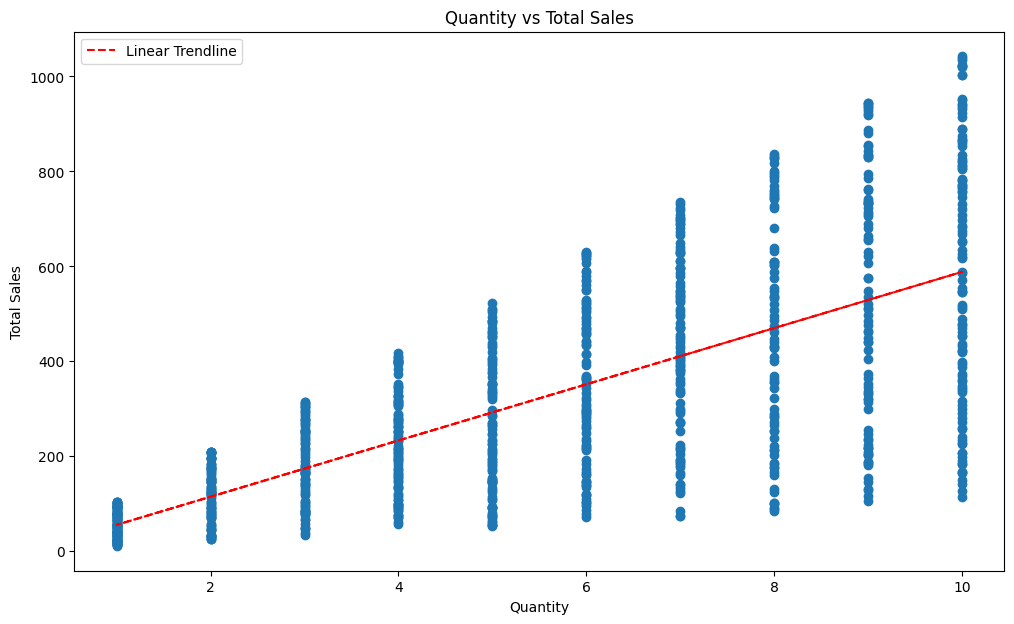

In [115]:
X = supermarket['Quantity']
Y = supermarket['Sales']

fig, ax = plt.subplots(figsize = (12, 7))
ax.scatter(X, Y)
ax.set_xlabel("Quantity")
ax.set_ylabel("Total Sales")
ax.set_title("Quantity vs Total Sales")

# Add a linear trend line
z = np.polyfit(X, Y, 1) # Calculate coefficients for a 1st degree polynomial (linear)
p = np.poly1d(z) # Create a polynomial function from the coefficients
ax.plot(X, p(X), color='red', linestyle='--', label='Linear Trendline')
ax.legend()

plt.show()

## Column Bar Chart

A bar chart showing the sum of Total revenue generated by
each of the three Branch locations (A, B, and C).

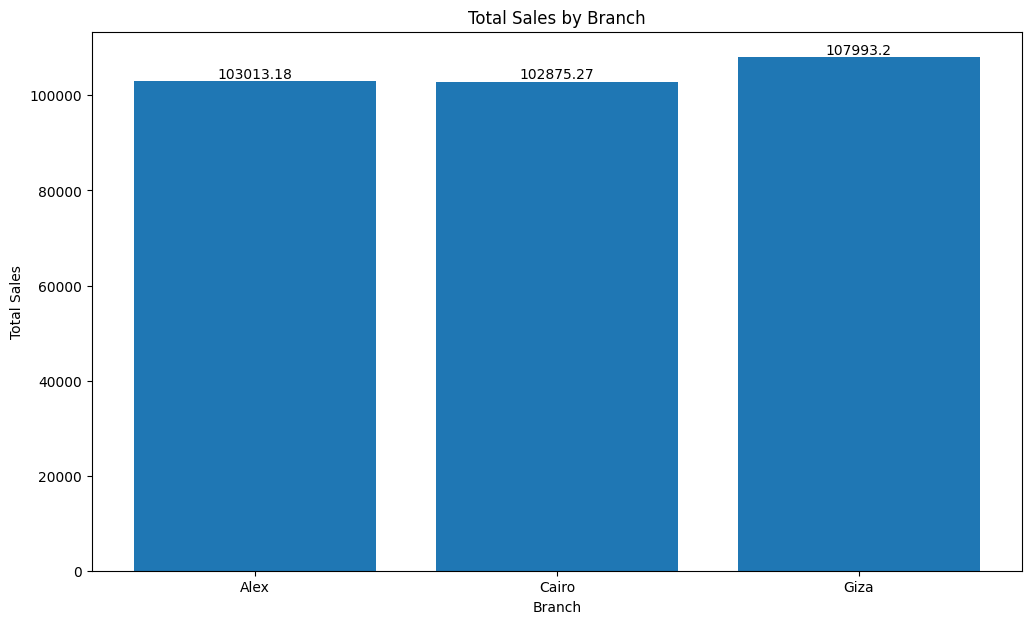

In [116]:
Z = supermarket['Sales'].groupby(supermarket['Branch']).sum()

fig, ax = plt.subplots(figsize = (12, 7))
bars = ax.bar(Z.index, Z)
ax.set_xlabel("Branch")
ax.set_ylabel("Total Sales")
ax.set_title("Total Sales by Branch")

# Add total sales value on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 10, round(yval, 2), ha='center', va='bottom') # +10 for a little padding above the bar

plt.show()

## Pie Chart

A pie chart showing the proportion of transactions broken down by Payment method (Cash, Credit Card, Ewalet).

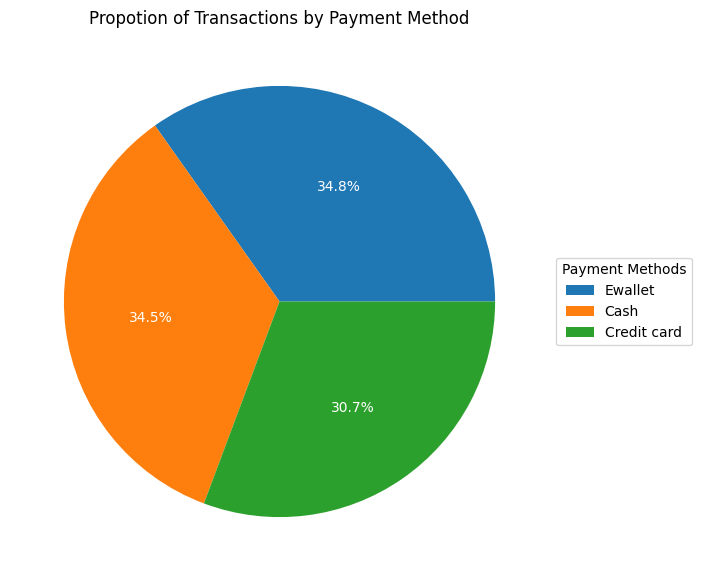

In [117]:
Z = supermarket['Payment'].value_counts()

fig, ax = plt.subplots(figsize = (12, 7))
wedges, texts, autotexts = ax.pie(Z, labels=Z.index, autopct='%1.1f%%', textprops={'color': 'white'})
ax.set_title("Propotion of Transactions by Payment Method")
ax.legend(wedges, Z.index, title="Payment Methods", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

## Histogram

A Histogram of the customer Rating column visualizing how satisfaction scores are distributed.

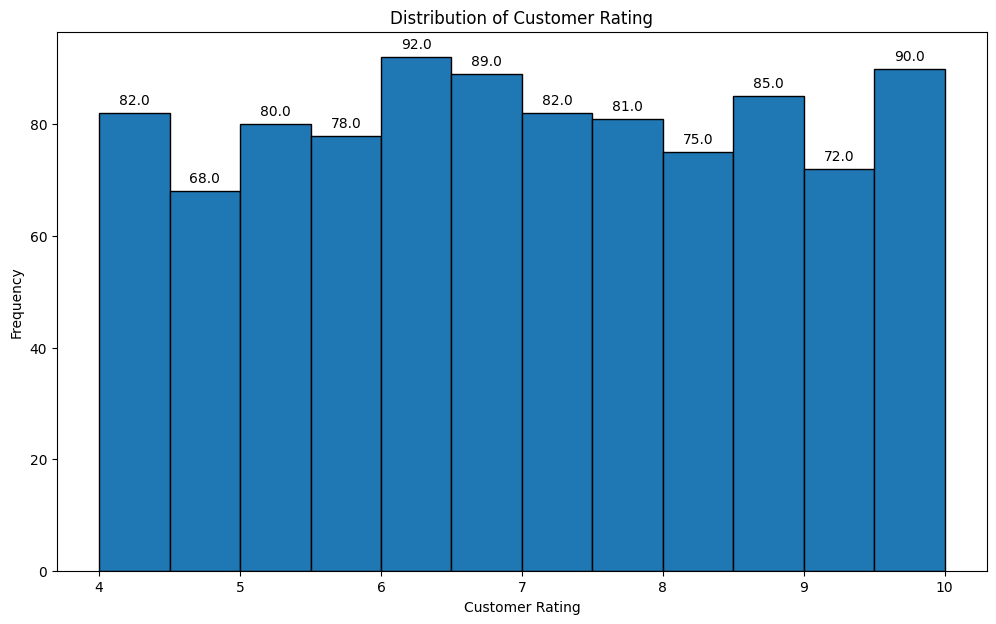

In [118]:
fig, ax = plt.subplots(figsize = (12, 7))
hist = ax.hist(supermarket['Rating'], bins=12, edgecolor='black')
ax.set_xlabel("Customer Rating")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Customer Rating")

# Iterate over the bars returned by ax.hist() to get the height and add the associated values.
for bar in hist[2]:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom') # yval +1 for a space between the bars and the text

plt.show()